# Assignment 6 — Linear Regression Using Gradient Descent

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score


## Part A: Dataset — Diabetes

In [3]:
diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target
print('Number of samples:', X.shape[0])
print('Number of features:', X.shape[1])
print('X shape:', X.shape)
print('y shape:', y.shape)



Number of samples: 442
Number of features: 10
X shape: (442, 10)
y shape: (442,)


## Train-Test Split and Standardization

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print('Training samples:', X_train.shape[0])
print('Testing samples:', X_test.shape[0])


Training samples: 353
Testing samples: 89


## Task 1: Simple Dataset

x = [1 2 3 4 5]
y = [ 3  5  7  8 11]
Number of training examples: 5


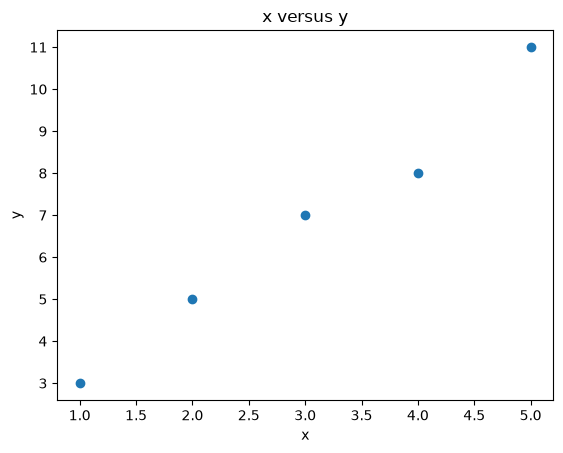

In [10]:
x = np.array([1, 2, 3, 4, 5])
y = np.array([3, 5, 7, 8, 11])
print('x =', x)
print('y =', y)
print('Number of training examples:', len(x))

plt.scatter(x, y)
plt.xlabel('x')
plt.ylabel('y')
plt.title('x versus y')
plt.show()


## Task 2: Initialize the Model

In [11]:
theta0 = 0
theta1 = 0
alpha = 0.01
iterations = 1000
print(theta0, theta1, alpha, iterations)


0 0 0.01 1000


## Task 3: Prediction

In [12]:
def predict(X, theta0, theta1):
    return theta0 + theta1 * X

predicted = predict(x, 0, 1)
print('Predicted values:', predicted)


Predicted values: [1 2 3 4 5]


## Task 4: Error

In [13]:
errors = predicted - y
print('Actual y:', y)
print('Predicted y:', predicted)
print('Error:', errors)


Actual y: [ 3  5  7  8 11]
Predicted y: [1 2 3 4 5]
Error: [-2 -3 -4 -4 -6]


## Task 5: Cost Function

In [14]:
def compute_cost(X, y, theta0, theta1):
    m = len(y)
    errors = predict(X, theta0, theta1) - y
    return np.sum(errors ** 2) / (2 * m)

cost = compute_cost(x, y, 0, 1)
print('Cost:', cost)


Cost: 8.1


## Task 6: Calculate the Gradients

In [15]:
theta0 = 0
theta1 = 1
alpha = 0.1
predicted = predict(x, theta0, theta1)
errors = predicted - y
m = len(y)
gradient_theta0 = np.sum(errors) / m
gradient_theta1 = np.sum(errors * x) / m
print('Predicted values:', predicted)
print('Errors:', errors)
print('dJ/dtheta0:', gradient_theta0)
print('dJ/dtheta1:', gradient_theta1)


Predicted values: [1 2 3 4 5]
Errors: [-2 -3 -4 -4 -6]
dJ/dtheta0: -3.8
dJ/dtheta1: -13.2


## Task 7: One Gradient-Descent Update

In [17]:
old_theta0 = theta0
old_theta1 = theta1
theta0 = theta0 - alpha * gradient_theta0
theta1 = theta1 - alpha * gradient_theta1
print('Old theta0:', old_theta0)
print('Old theta1:', old_theta1)
print('New theta0:', theta0)
print('New theta1:', theta1)


Old theta0: 0.38
Old theta1: 2.3200000000000003
New theta0: 0.76
New theta1: 3.6400000000000006


## Task 8: Complete Training Algorithm

In [18]:
def fit(X, y, lr=0.01, n_iters=1000):
    theta0 = 0.0
    theta1 = 0.0
    costs = []
    m = len(y)
    for _ in range(n_iters):
        predictions = predict(X, theta0, theta1)
        errors = predictions - y
        theta0 -= lr * np.sum(errors) / m
        theta1 -= lr * np.sum(errors * X) / m
        costs.append(compute_cost(X, y, theta0, theta1))
    return theta0, theta1, costs

x_train = np.array([1, 2, 3, 4, 5])
y_train = np.array([3, 5, 7, 8, 11])
theta0, theta1, costs = fit(x_train, y_train, lr=0.01, n_iters=1000)
print('Final theta0:', theta0)
print('Final theta1:', theta1)


Final theta0: 1.0018665097501784
Final theta1: 1.927181403223624


## Task 9: Learning Curve

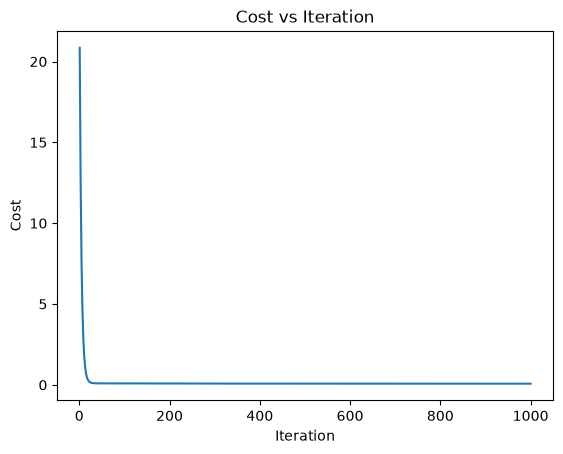

In [19]:
plt.plot(range(1, len(costs) + 1), costs)
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Cost vs Iteration')
plt.show()


**Observation:** The cost curve shows us that the cost function shows a sharp a decline during first few iterations, owing to the fact that the dataset is small and very close to having an perfect analytic solution. after that it remains close to y=0 and does not change much.

## Task 10: Best-Fit Line

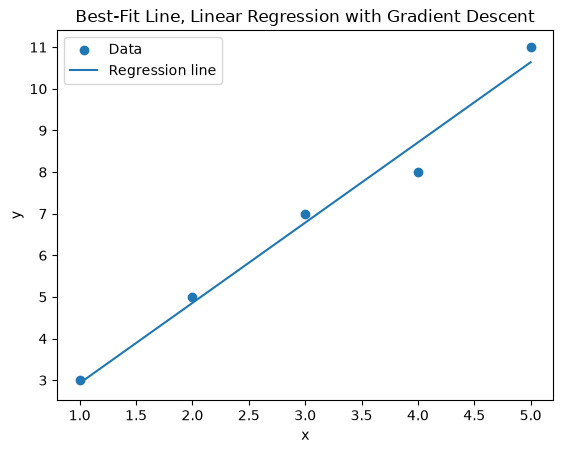

In [21]:
predictions = predict(x_train, theta0, theta1)
plt.scatter(x_train, y_train, label='Data')
plt.plot(x_train, predictions, label='Regression line')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Best-Fit Line, Linear Regression with Gradient Descent')
plt.legend()
plt.show()


## Task 11: Predict New Values

In [22]:
new_x = np.array([6, 7, 8, 10])
new_y = predict(new_x, theta0, theta1)
results = pd.DataFrame({'x': new_x, 'Predicted y': new_y})
results


,x,Predicted y
0,6,12.564955
1,7,14.492136
2,8,16.419318
3,10,20.273681


## Task 12: Effect of Learning Rate

In [23]:
learning_rates = [0.001, 0.01, 0.1]
learning_rate_results = []

for lr in learning_rates:
    t0, t1, c = fit(x_train, y_train, lr=lr, n_iters=1000)
    learning_rate_results.append([lr, t0, t1, c[-1]])

lr_results = pd.DataFrame(
    learning_rate_results,
    columns=['Learning Rate', 'theta0', 'theta1', 'Final Cost']
)
lr_results


,Learning Rate,theta0,theta1,Final Cost
0,0.001,0.650028,2.024620,0.088427
1,0.010,1.001867,1.927181,0.070876
2,0.100,1.100000,1.900000,0.070000


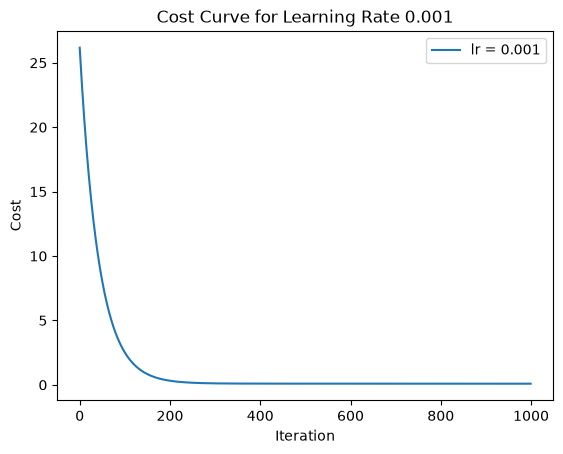

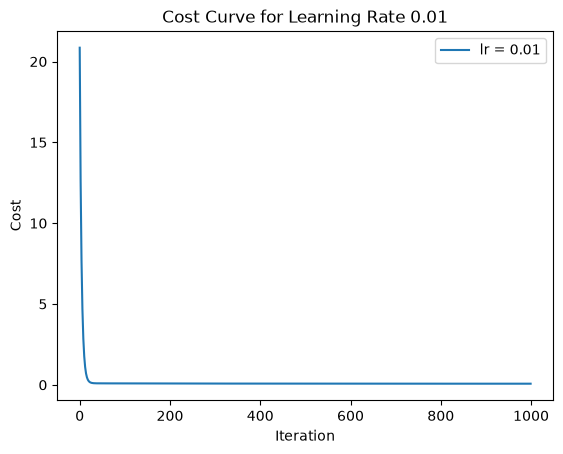

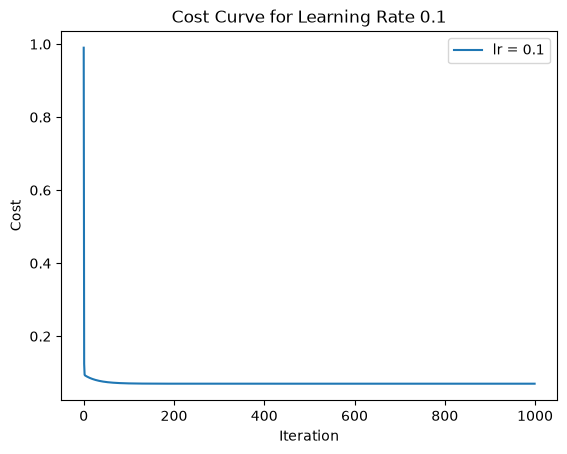

In [24]:
for lr in learning_rates:
    _, _, c = fit(x_train, y_train, lr=lr, n_iters=1000)
    plt.plot(c, label=f'lr = {lr}')
    plt.xlabel('Iteration')
    plt.ylabel('Cost')
    plt.title(f'Cost Curve for Learning Rate {lr}')
    plt.legend()
    plt.show()


**Effect of Learning Rate** : Lowering learning rate makes the model learn slowly. But the curve shows that the lr=0.001 also gives the smoothest curve, which means that the model will reach a solution in a more stable manner for more complicated problem (less chance of oscillating around the solution).

## Task 13: Analytical Solution

In [25]:
x = np.array([1, 2, 3, 4, 5], dtype=float)
y = np.array([3, 5, 7, 8, 11], dtype=float)
m = len(x)
sum_x = np.sum(x)
sum_y = np.sum(y)
sum_xy = np.sum(x * y)
sum_x2 = np.sum(x ** 2)
x_bar = np.mean(x)
y_bar = np.mean(y)
theta1_closed = (m * sum_xy - sum_x * sum_y) / (m * sum_x2 - sum_x ** 2)
theta0_closed = y_bar - theta1_closed * x_bar

print('Sum x:', sum_x)
print('Sum y:', sum_y)
print('Sum xy:', sum_xy)
print('Sum x^2:', sum_x2)
print('x mean:', x_bar)
print('y mean:', y_bar)
print('theta1:', theta1_closed)
print('theta0:', theta0_closed)
print('Regression equation: y_hat = theta0 + theta1*x')


Sum x: 15.0
Sum y: 34.0
Sum xy: 121.0
Sum x^2: 55.0
x mean: 3.0
y mean: 6.8
theta1: 1.9
theta0: 1.1000000000000005
Regression equation: y_hat = theta0 + theta1*x


## Task 14: Gradient Descent vs Analytical Solution

In [27]:
theta0_gd_001, theta1_gd_001, costs_gd_001 = fit(x, y, lr=0.001, n_iters=1000)
cost_gd_001 = compute_cost(x, y, theta0_gd_001, theta1_gd_001)
theta0_gd_01, theta1_gd_01, costs_gd_01 = fit(x, y, lr=0.01, n_iters=1000)
cost_gd_01 = compute_cost(x, y, theta0_gd_01, theta1_gd_01)
theta0_gd_1, theta1_gd_1, costs_gd_1 = fit(x, y, lr=0.1, n_iters=1000)
cost_gd_1 = compute_cost(x, y, theta0_gd_1, theta1_gd_1)
cost_closed = compute_cost(x, y, theta0_closed, theta1_closed)

comparison = pd.DataFrame({
    'Method': ['GD (LR=0.001)', 'GD (LR=0.01)', 'GD (LR=0.1)', 'Analytical Solution'],
    'theta0': [theta0_gd_001, theta0_gd_01, theta0_gd_1, theta0_closed],
    'theta1': [theta1_gd_001, theta1_gd_01, theta1_gd_1, theta1_closed],
    'Cost': [cost_gd_001, cost_gd_01, cost_gd_1, cost_closed]
})
comparison


,Method,theta0,theta1,Cost
0,GD (LR=0.001),0.650028,2.024620,0.088427
1,GD (LR=0.01),1.001867,1.927181,0.070876
2,GD (LR=0.1),1.100000,1.900000,0.070000
3,Analytical Solution,1.100000,1.900000,0.070000


The parameters from gradient descent may differ from the analytical solution when training is stopped after a finite number of iterations. The model tries to reach the analytical solution numerically, but if it is stopped early, it might not reach there.

## Part H: Multiple Linear Regression

In [28]:
X_multi = np.array([
    [1000, 2],
    [1200, 2],
    [1500, 3],
    [1800, 3],
    [2000, 4]
], dtype=float)
y_multi = np.array([50, 60, 75, 90, 105], dtype=float)


In [29]:
def fit_multiple(X, y, lr=0.01, n_iters=1000):
    theta = np.zeros(X.shape[1])
    theta0 = 0.0
    m = len(y)
    costs = []
    for _ in range(n_iters):
        predictions = theta0 + X @ theta
        errors = predictions - y
        theta0 -= lr * np.mean(errors)
        theta -= lr * (X.T @ errors) / m
        costs.append(np.sum(errors ** 2) / (2 * m))
    return theta0, theta, costs


In [30]:
X_multi_scaled = StandardScaler().fit_transform(X_multi)
theta0_multi, theta_multi, costs_multi = fit_multiple(
    X_multi_scaled, y_multi, lr=0.01, n_iters=1000
)
print('Final bias:', theta0_multi)
print('Final weights:', theta_multi)


Final bias: 75.99671898519674
Final weights: [13.09251942  6.8703531 ]


## Task 16: Prediction with Multiple Features

In [31]:
house = np.array([[1600, 3]], dtype=float)
multi_scaler = StandardScaler()
X_multi_scaled = multi_scaler.fit_transform(X_multi)
house_scaled = multi_scaler.transform(house)
price_prediction = theta0_multi + house_scaled @ theta_multi
print('Predicted price:', price_prediction[0])


Predicted price: 81.38310587559624


## Diabetes Regression

In [32]:
diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target
print('Number of samples:', X.shape[0])
print('Number of features:', X.shape[1])
print('X shape:', X.shape)
print('y shape:', y.shape)

Number of samples: 442
Number of features: 10
X shape: (442, 10)
y shape: (442,)


In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print('Training samples:', X_train.shape[0])
print('Testing samples:', X_test.shape[0])


Training samples: 353
Testing samples: 89


In [34]:
def fit_linear_regression(X, y, lr=0.01, n_iters=1000):
    theta = np.zeros(X.shape[1])
    bias = 0.0
    m = len(y)
    costs = []
    for _ in range(n_iters):
        predictions = bias + X @ theta
        errors = predictions - y
        bias -= lr * np.mean(errors)
        theta -= lr * (X.T @ errors) / m
        costs.append(np.sum(errors ** 2) / (2 * m))
    return bias, theta, costs

bias, weights, diabetes_costs = fit_linear_regression(
    X_train, y_train, lr=0.01, n_iters=1000
)
y_pred = bias + X_test @ weights
print('MSE:', mean_squared_error(y_test, y_pred))
print('R2:', r2_score(y_test, y_pred))


MSE: 2884.922802987494
R2: 0.45548505593573707


## Diabetes Training Loss

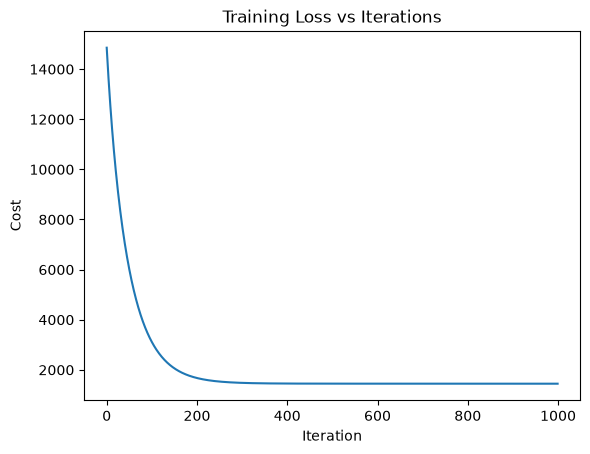

In [35]:
plt.plot(diabetes_costs)
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Training Loss vs Iterations')
plt.show()


## Diabetes Learning-Rate Comparison

In [36]:
diabetes_lr_results = []
diabetes_lr_curves = {}

for lr in [0.001, 0.01, 0.1]:
    b, w, c = fit_linear_regression(X_train, y_train, lr=lr, n_iters=1000)
    diabetes_lr_results.append([lr, b, c[-1]])
    diabetes_lr_curves[lr] = c

pd.DataFrame(diabetes_lr_results, columns=['Learning Rate', 'Bias', 'Final Cost'])


,Learning Rate,Bias,Final Cost
0,0.001,97.208320,3130.603270
1,0.010,153.729907,1447.372449
2,0.100,153.736544,1436.760568


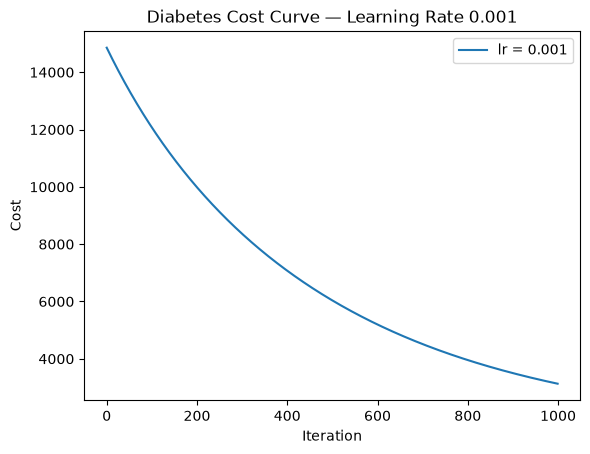

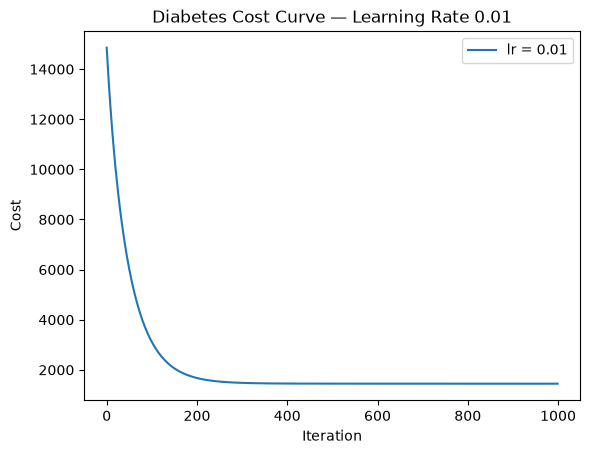

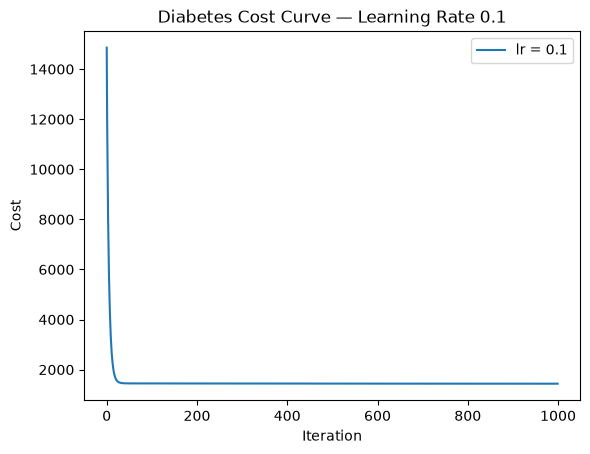

In [37]:
for lr, costs in diabetes_lr_curves.items():
    plt.plot(costs, label=f'lr = {lr}')
    plt.xlabel('Iteration')
    plt.ylabel('Cost')
    plt.title(f'Diabetes Cost Curve — Learning Rate {lr}')
    plt.legend()
    plt.show()


## Comparison with sklearn LinearRegression

In [39]:
from sklearn.linear_model import LinearRegression

sk_model = LinearRegression()
sk_model.fit(X_train, y_train)
sk_pred = sk_model.predict(X_test)
sklearn_comparison = pd.DataFrame({
    'Metric': ['MSE', 'R2'],
    'Our Method': [mean_squared_error(y_test, y_pred), r2_score(y_test, y_pred)],
    'sklearn LinearRegression': [mean_squared_error(y_test, sk_pred), r2_score(y_test, sk_pred)]
})
sklearn_comparison


,Metric,Our Method,sklearn LinearRegression
0,MSE,2884.922803,2900.193628
1,R2,0.455485,0.452603
